<a href="https://colab.research.google.com/github/catalinagaviriamet-spec/Ciencia-de-datos/blob/main/Ejercicio_DataAdults.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Trabajo final para Introducción a la Ciencia de Datos

Integrantes:
Yerlith Judith Zabala Martinez,
Carolina Tirado Osorio,
Ana Catalina Gaviria Metaute.

#DataSet utilizado:
Datos sociodemográficos y económicos de adultos con variables como edad, género, raza, nivel de estudio, ganancias, pérdidas, entre otras.

#Target: Ingresos anuales superiores a 50,000 UDS al año
Con la información existente se requiere identificar las variables determinantes para predecir si una persona tendrá ingresos superiores a 50,000 USD al año.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/adult-all.csv"

columnas_es = [
    "edad",
    "tipo_trabajo",
    "peso_muestral",
    "nivel_educativo",
    "anios_educacion",
    "estado_civil",
    "ocupacion",
    "relacion_familiar",
    "raza",
    "sexo",
    "ganancia_capital",
    "perdida_capital",
    "horas_por_semana",
    "pais_origen",
    "ingresos"
]

df = pd.read_csv(url, header=None, names=columnas_es)
df.head()

print('Shape inicial:', df.shape)
display(df.head())

Shape inicial: (48842, 15)


,edad,tipo_trabajo,peso_muestral,nivel_educativo,anios_educacion,estado_civil,ocupacion,relacion_familiar,raza,sexo,ganancia_capital,perdida_capital,horas_por_semana,pais_origen,ingresos
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Se muestra que la base de datos elegida contiene un total de 48,842 registros con 15 columnas.

**Exploración Inicial del dataset**: estructura, estadística y valores faltantes

In [2]:
df.describe()

,edad,peso_muestral,anios_educacion,ganancia_capital,perdida_capital,horas_por_semana
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [3]:
mediana = df["horas_por_semana"].median() ##se calcula para reforzar dsitribución de los datos de "horas por semana" que se tiene mas adelante.
print(mediana)

40.0


Del resumen numérico se observa lo siguiente:
1. La edad promedio de las persona es de 38 años, y en promedio han cursado 10 años de educación.
2. La edad mínima de la población de de 17 años y la máxima es de 90.
3. En promedio las personas trabajan 40 horas a la semana, y el máximo de horas trabajadas son 99.
4. Comparando los mínimos y los máximos contra los cuartiles, así como la desviación estándar respecto a la media, se identifican valores outliers en las columnas edad, ganancia_capital, perdida_capital y horas_por_semana, debido a que los máximos están muy alejados del q3 y la std para algunas viriables está muy alta respecto a la media.

In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   edad               48842 non-null  int64 
 1   tipo_trabajo       48842 non-null  object
 2   peso_muestral      48842 non-null  int64 
 3   nivel_educativo    48842 non-null  object
 4   anios_educacion    48842 non-null  int64 
 5   estado_civil       48842 non-null  object
 6   ocupacion          48842 non-null  object
 7   relacion_familiar  48842 non-null  object
 8   raza               48842 non-null  object
 9   sexo               48842 non-null  object
 10  ganancia_capital   48842 non-null  int64 
 11  perdida_capital    48842 non-null  int64 
 12  horas_por_semana   48842 non-null  int64 
 13  pais_origen        48842 non-null  object
 14  ingresos           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


,0
edad,0
tipo_trabajo,0
peso_muestral,0
nivel_educativo,0
anios_educacion,0
estado_civil,0
ocupacion,0
relacion_familiar,0
raza,0
sexo,0


Se observa que de las 15 variables del dataset, el 40% son numéricas, y el 60% son categóricas. Adicionalmente, ninguna de las variables tiene valores nulos.

In [5]:
df.isin(["?"]).sum()

,0
edad,0
tipo_trabajo,2799
peso_muestral,0
nivel_educativo,0
anios_educacion,0
estado_civil,0
ocupacion,2809
relacion_familiar,0
raza,0
sexo,0


In [5]:
df.replace("?", pd.NA, inplace=True)

Se identifican valores con el caracter "?" y se reemplazan por NA.

In [6]:
print('\nResumen categórico:')
display(df.describe(include='object'))


Resumen categórico:


,tipo_trabajo,nivel_educativo,estado_civil,ocupacion,relacion_familiar,raza,sexo,pais_origen,ingresos
count,48842,48842,48842,48842,48842,48842,48842,48842,48842
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,33906,15784,22379,6172,19716,41762,32650,43832,37155


Según el resumen categórico, se tienen 9 tipos de trabajo, 7 estados civiles, 15 ocupaciones, entre otros. En el top de tipo_trabajo resalta el Private, y la base tiene mas hombres que mujeres. Adicional, el país_origen que mas se presenta es Estados Unidos.

**Análisis descriptivo y resumenes pivotes**: Distribución de valores por columna

In [7]:
for col in df.columns:
    print(f"\n🔹 {col}")
    print(df[col].value_counts())


🔹 edad
edad
36    1348
35    1337
33    1335
23    1329
31    1325
      ... 
88       6
85       5
87       3
89       2
86       1
Name: count, Length: 74, dtype: int64

🔹 tipo_trabajo
tipo_trabajo
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
?                    2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

🔹 peso_muestral
peso_muestral
203488    21
120277    19
190290    19
126569    18
125892    18
          ..
275677     1
311631     1
374763     1
242136     1
26711      1
Name: count, Length: 28523, dtype: int64

🔹 nivel_educativo
nivel_educativo
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th

In [8]:
cols = ["relacion_familiar", "raza", "sexo", "pais_origen"]

for col in cols:
    print(f"\n🔹 {col.upper()}")
    print(df[col].value_counts())


🔹 RELACION_FAMILIAR
relacion_familiar
Husband           19716
Not-in-family     12583
Own-child          7581
Unmarried          5125
Wife               2331
Other-relative     1506
Name: count, dtype: int64

🔹 RAZA
raza
White                 41762
Black                  4685
Asian-Pac-Islander     1519
Amer-Indian-Eskimo      470
Other                   406
Name: count, dtype: int64

🔹 SEXO
sexo
Male      32650
Female    16192
Name: count, dtype: int64

🔹 PAIS_ORIGEN
pais_origen
United-States                 43832
Mexico                          951
?                               857
Philippines                     295
Germany                         206
Puerto-Rico                     184
Canada                          182
El-Salvador                     155
India                           151
Cuba                            138
England                         127
China                           122
South                           115
Jamaica                         106
Italy     

Proporciones % Genero, pais, sexo.

In [9]:
for col in cols:
    print(f"\n🔹 {col.upper()} (%)")
    print((df[col].value_counts(normalize=True)*100).round(2))


🔹 RELACION_FAMILIAR (%)
relacion_familiar
Husband           40.37
Not-in-family     25.76
Own-child         15.52
Unmarried         10.49
Wife               4.77
Other-relative     3.08
Name: proportion, dtype: float64

🔹 RAZA (%)
raza
White                 85.50
Black                  9.59
Asian-Pac-Islander     3.11
Amer-Indian-Eskimo     0.96
Other                  0.83
Name: proportion, dtype: float64

🔹 SEXO (%)
sexo
Male      66.85
Female    33.15
Name: proportion, dtype: float64

🔹 PAIS_ORIGEN (%)
pais_origen
United-States                 89.74
Mexico                         1.95
?                              1.75
Philippines                    0.60
Germany                        0.42
Puerto-Rico                    0.38
Canada                         0.37
El-Salvador                    0.32
India                          0.31
Cuba                           0.28
England                        0.26
China                          0.25
South                          0.24
Jamaica  

In [10]:
df["horas_por_semana"].value_counts().head(10)

,count
horas_por_semana,
40,22803
50,4246
45,2717
60,2177
35,1937
20,1862
30,1700
55,1051
25,958


Sexo vs ingresos

In [11]:
pd.crosstab(df["sexo"], df["ingresos"], normalize="index")*100

ingresos,<=50K,>50K
sexo,,
Female,89.074852,10.925148
Male,69.623277,30.376723


Relación familiar vs ingresos

In [12]:
pd.crosstab(df["relacion_familiar"], df["ingresos"], normalize="index")*100

ingresos,<=50K,>50K
relacion_familiar,,
Husband,55.132887,44.867113
Not-in-family,89.859334,10.140666
Other-relative,96.547145,3.452855
Own-child,98.535813,1.464187
Unmarried,93.970732,6.029268
Wife,53.110253,46.889747


Top Paises


In [13]:
top_paises = df["pais_origen"].value_counts().head(5).index

pd.crosstab(df[df["pais_origen"].isin(top_paises)]["pais_origen"],
            df["ingresos"], normalize="index")*100

ingresos,<=50K,>50K
pais_origen,,
?,74.329055,25.670945
Germany,71.844660,28.155340
Mexico,95.057834,4.942166
Philippines,71.186441,28.813559
United-States,75.602300,24.397700


“En promedio, quienes ganan más trabajan X horas vs Y horas”

In [14]:
df.groupby("ingresos")["horas_por_semana"].mean()

,horas_por_semana
ingresos,
<=50K,38.840048
>50K,45.452896


“El análisis exploratorio muestra diferencias importantes en la distribución de ingresos según variables demográficas como género, relación familiar y país de origen, además de una relación con la cantidad de horas trabajadas.”

**Calidad de datos**: nulos, duplicados y algunas validaciones básicas

In [15]:
df.isna().sum()

,0
edad,0
tipo_trabajo,0
peso_muestral,0
nivel_educativo,0
anios_educacion,0
estado_civil,0
ocupacion,0
relacion_familiar,0
raza,0
sexo,0


In [16]:
df.nunique(dropna=False)

,0
edad,74
tipo_trabajo,9
peso_muestral,28523
nivel_educativo,16
anios_educacion,16
estado_civil,7
ocupacion,15
relacion_familiar,6
raza,5
sexo,2


In [17]:
quality = pd.DataFrame({
    'nulos': df.isna().sum(),
    'pct_nulos': (df.isna().mean() * 100).round(2),
    'n_unicos': df.nunique(dropna=False)
}).sort_values('pct_nulos', ascending=False)

display(quality)

print('Filas duplicadas:', df.duplicated().sum())
print('ganancia_capital negativos:', (df['ganancia_capital'] < 0).sum())
print('edad negativos:', (df['edad'] < 0).sum())
print('horas_por_semana negativos:', (df['horas_por_semana'] < 0).sum())

,nulos,pct_nulos,n_unicos
edad,0,0.0,74
tipo_trabajo,0,0.0,9
peso_muestral,0,0.0,28523
nivel_educativo,0,0.0,16
anios_educacion,0,0.0,16
estado_civil,0,0.0,7
ocupacion,0,0.0,15
relacion_familiar,0,0.0,6
raza,0,0.0,5
sexo,0,0.0,2


Filas duplicadas: 52
ganancia_capital negativos: 0
edad negativos: 0
horas_por_semana negativos: 0


Se identifica 52 filas duplicadas que se deben eliminar, y se comprueba que no hay valores negativos incongruentes.

**Limpieza de datos**: eliminación de filas; agrupación de categorías para mejor análisis.

In [18]:
df = df.drop_duplicates()
print('Shape final:', df.shape)
display(df.head())

Shape final: (48790, 15)


,edad,tipo_trabajo,peso_muestral,nivel_educativo,anios_educacion,estado_civil,ocupacion,relacion_familiar,raza,sexo,ganancia_capital,perdida_capital,horas_por_semana,pais_origen,ingresos
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Se eliminan las 52 filas repetidas, quedando con un dataset de 48,790 registros

**Feature engineering**: crear nuevas variables para mejorar el análisis

In [19]:
bins = [17, 25, 35, 60, 99]
labels = ['Joven', 'Joven adulto', 'Adulto', 'Adulto mayor']
df["grupo_edad"] = pd.cut(
    df["edad"],
    bins=bins,
    labels=labels,
    right=True
)
df['grupo_edad'].value_counts()

,count
grupo_edad,
Adulto,22876
Joven adulto,12710
Joven,9005
Adulto mayor,3605


In [20]:
region_map = {
    # Norteamérica
    "United-States": "Norteamérica",
    "Canada": "Norteamérica",
    "Mexico": "Norteamérica",
    "Puerto-Rico": "Norteamérica",
    "Outlying-US(Guam-USVI-etc)": "Norteamérica",

    # Latinoamérica y Caribe
    "El-Salvador": "Latinoamérica",
    "Cuba": "Latinoamérica",
    "Jamaica": "Latinoamérica",
    "Dominican-Republic": "Latinoamérica",
    "Guatemala": "Latinoamérica",
    "Haiti": "Latinoamérica",
    "Nicaragua": "Latinoamérica",
    "Peru": "Latinoamérica",
    "Ecuador": "Latinoamérica",
    "Columbia": "Latinoamérica",
    "Honduras": "Latinoamérica",
    "Trinadad&Tobago": "Latinoamérica",

    # Europa
    "Germany": "Europa",
    "England": "Europa",
    "Italy": "Europa",
    "Poland": "Europa",
    "Portugal": "Europa",
    "Greece": "Europa",
    "France": "Europa",
    "Ireland": "Europa",
    "Scotland": "Europa",
    "Hungary": "Europa",
    "Yugoslavia": "Europa",
    "Holand-Netherlands": "Europa",

    # Asia
    "Philippines": "Asia",
    "India": "Asia",
    "China": "Asia",
    "Japan": "Asia",
    "Vietnam": "Asia",
    "Taiwan": "Asia",
    "Iran": "Asia",
    "Thailand": "Asia",
    "Hong": "Asia",
    "Cambodia": "Asia",
    "Laos": "Asia",

    # Otros
    "South": "Otros"
}
df["region"] = df["pais_origen"].map(region_map)
df['region'].value_counts()

,count
region,
Norteamérica,45124
Asia,980
Latinoamérica,935
Europa,780
Otros,115


In [21]:
df

,edad,tipo_trabajo,peso_muestral,nivel_educativo,anios_educacion,estado_civil,ocupacion,relacion_familiar,raza,sexo,ganancia_capital,perdida_capital,horas_por_semana,pais_origen,ingresos,grupo_edad,region
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,Adulto,Norteamérica
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,Adulto,Norteamérica
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,Adulto,Norteamérica
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,Adulto,Norteamérica
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,Joven adulto,Latinoamérica
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K,Adulto,Norteamérica
48838,64,?,321403,HS-grad,9,Widowed,?,Other-relative,Black,Male,0,0,40,United-States,<=50K,Adulto mayor,Norteamérica
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K,Adulto,Norteamérica
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K,Adulto,Norteamérica


Dado que las variables edad y pais_origen tienen demasiados valores diferentes se decide clusterizarlas, creando dos variables nuevas: rango_edad y region, tal como se muestra en las dos últimas columnas de la visualización anterior del dataset, quedando con 17 columnas.

Visualizaciòn de Datos


In [22]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [23]:


# Limpiar nombres de columnas
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Limpiar strings en todo el dataframe
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip().str.lower()

# Crear variable numérica de ingresos (robusta)
df['income_num'] = df['ingresos'].apply(
    lambda x: 1 if '>50k' in x else 0 if '<=50k' in x else None
)

# Eliminar nulos en income
df = df[df['income_num'].notna()]

### Visualizaciones Comparativas

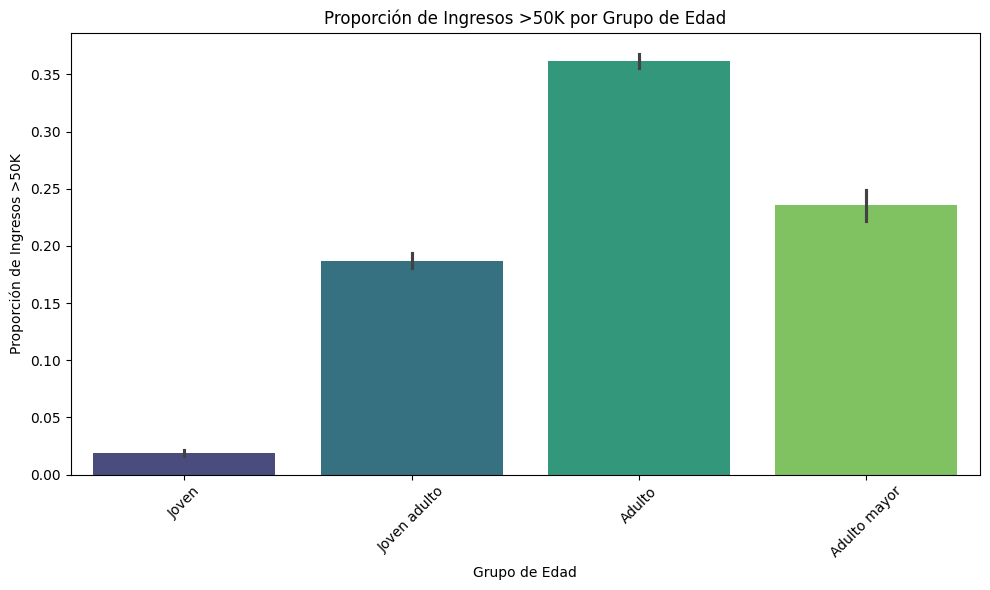

In [24]:


fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(x='grupo_edad', y='income_num', data=df, ax=ax, palette='viridis', hue='grupo_edad', legend=False)
ax.set_title('Proporción de Ingresos >50K por Grupo de Edad')
ax.set_xlabel('Grupo de Edad')
ax.set_ylabel('Proporción de Ingresos >50K')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Se observa que el rango de edad mas productivo donde se generan mayores ingresos es "Adulto", correspondiente al rango de edad de 35 a 59 años. Esto era lo esperado.

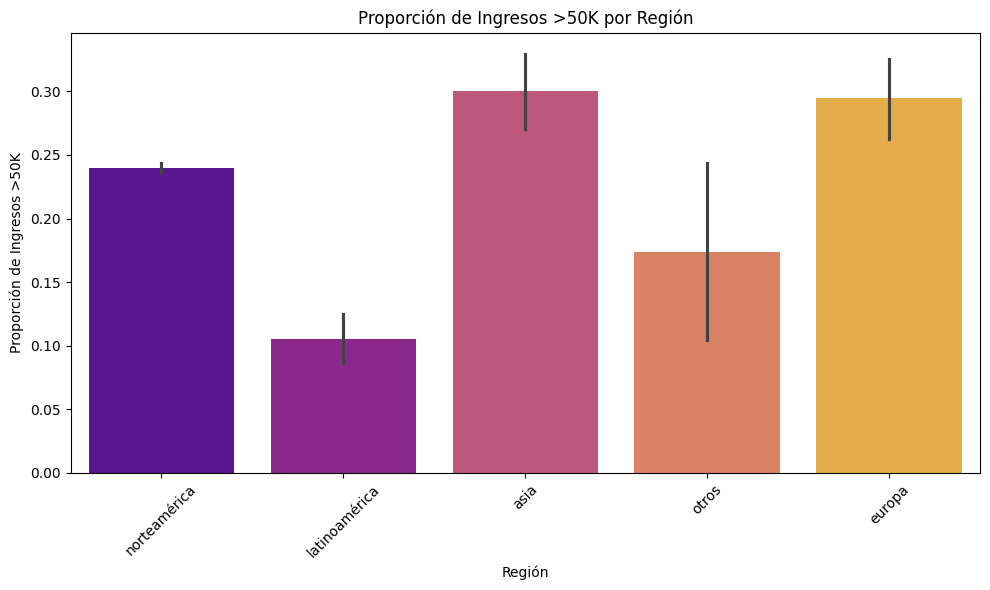

In [25]:


fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(x='region', y='income_num', data=df, ax=ax, palette='plasma', hue='region', legend=False)
ax.set_title('Proporción de Ingresos >50K por Región')
ax.set_xlabel('Región')
ax.set_ylabel('Proporción de Ingresos >50K')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

En la revisión de ingresos por Región, se ve claramente que Asia y Europa tienen los mayores ingresos, seguidos por Norteamérica. En el peor puesto se encuentra Latinoamérica.

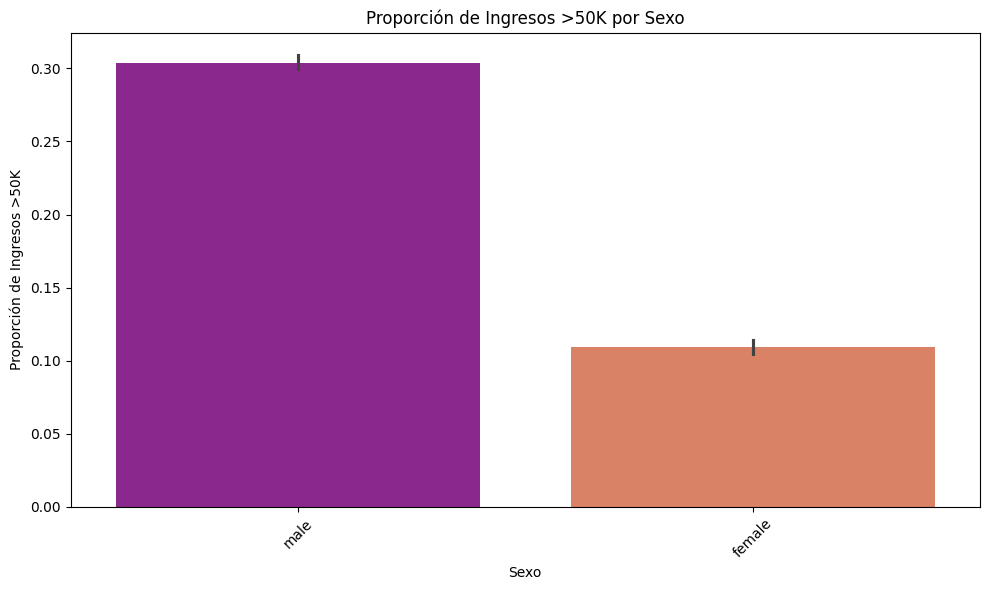

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(x='sexo', y='income_num', data=df, ax=ax, palette='plasma', hue='sexo', legend=False)
ax.set_title('Proporción de Ingresos >50K por Sexo')
ax.set_xlabel('Sexo')
ax.set_ylabel('Proporción de Ingresos >50K')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Se observa una brecha de ingresos muy marcada por el sexo de la persona, teniendo una proporción de ingresos mucho mayor para los hombres.

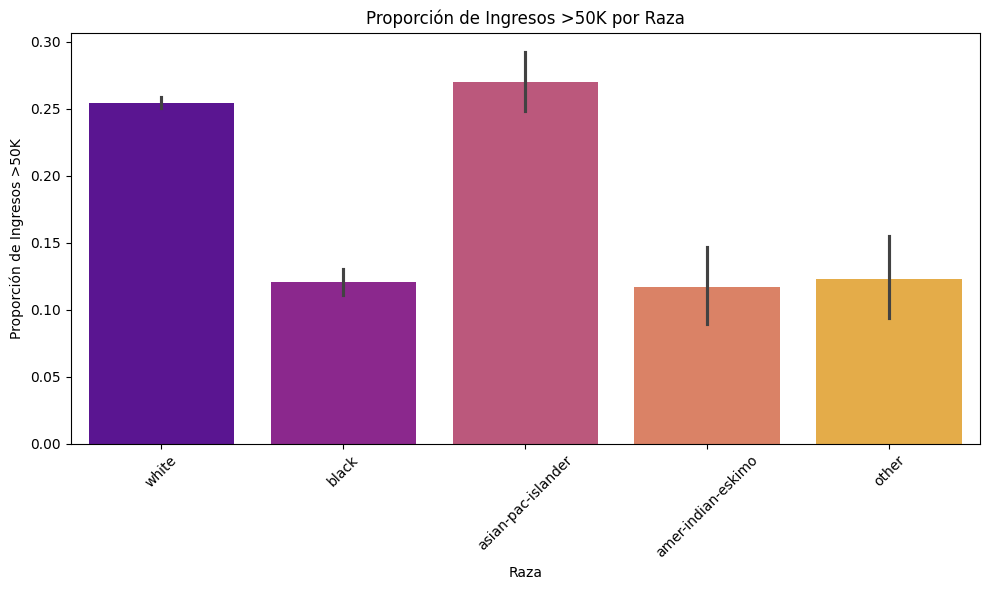

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(x='raza', y='income_num', data=df, ax=ax, palette='plasma', hue='raza', legend=False)
ax.set_title('Proporción de Ingresos >50K por Raza')
ax.set_xlabel('Raza')
ax.set_ylabel('Proporción de Ingresos >50K')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

También se observa una brecha marcada de ingresos entre personas de raza blanca y asiatica versus las demás.

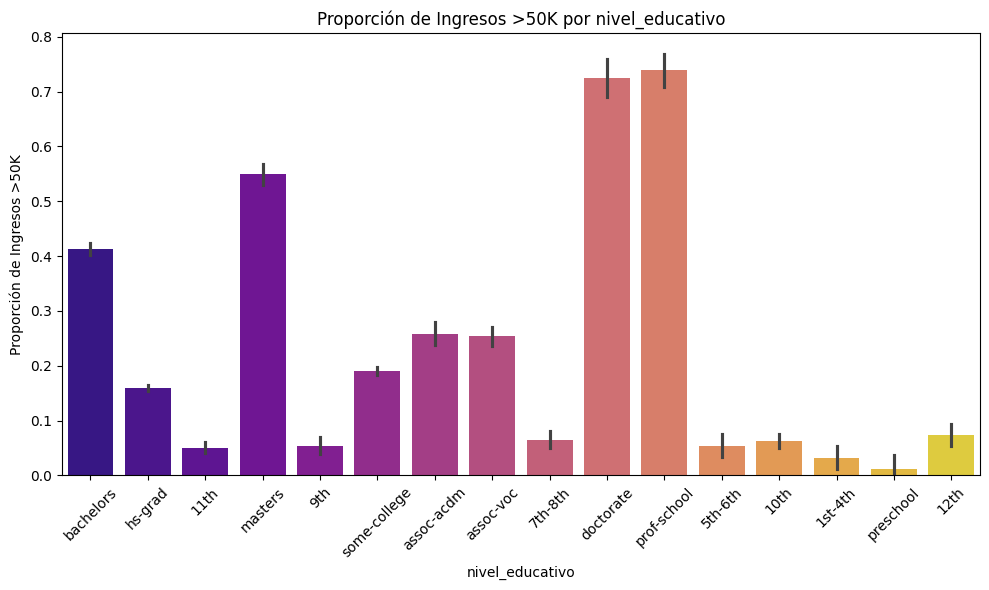

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(x='nivel_educativo', y='income_num', data=df, ax=ax, palette='plasma', hue='nivel_educativo', legend=False)
ax.set_title('Proporción de Ingresos >50K por nivel_educativo')
ax.set_xlabel('nivel_educativo')
ax.set_ylabel('Proporción de Ingresos >50K')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Para el nivel educativo se muestra lo esperado y es que a mayor grado de educación, mejores ingresos.

### Distribución de Horas por Semana

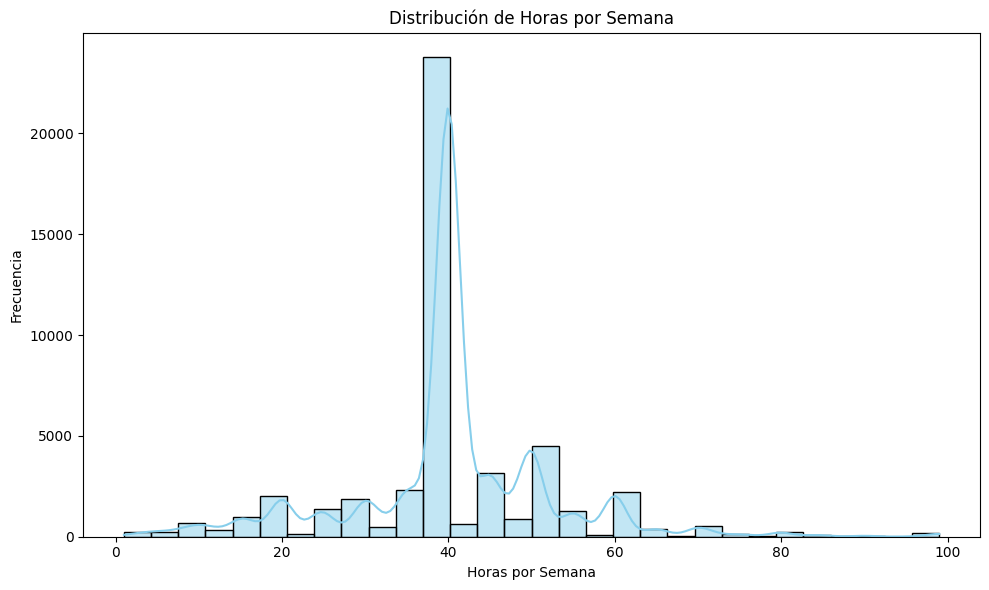

In [26]:


fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(df['horas_por_semana'], bins=30, kde=True, ax=ax, color='skyblue')
ax.set_title('Distribución de Horas por Semana')
ax.set_xlabel('Horas por Semana')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

Este Histograma muestra una distribución asimétrica, con una cola muy pronunciada a la derecha. Pero al tratarse de horas laborales donde la media y la mediana son 40, se puede hablar de una normal truncada.

### Preparación para Regresión Lineal y Escalado de Datos

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Seleccionar características numéricas para la regresión
# Excluimos 'peso_muestral' por su alta cardinalidad y naturaleza de 'sampling weight'
# 'income_num' es nuestro objetivo binario (0 o 1)

features = ['edad', 'anios_educacion', 'ganancia_capital', 'perdida_capital', 'horas_por_semana']
X = df[features]
y = df['income_num']

# Manejar valores NaN en las características (si los hubiera, aunque info() dice que no hay)
# En este dataset, las columnas numéricas no tienen nulos después de la limpieza inicial
# y la creación de income_num, pero es una buena práctica incluirlo.
X = X.fillna(X.mean())

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Escalado de características numéricas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Dimensiones de los datos de entrenamiento escalados:", X_train_scaled.shape)
print("Dimensiones de los datos de prueba escalados:", X_test_scaled.shape)

Dimensiones de los datos de entrenamiento escalados: (34153, 5)
Dimensiones de los datos de prueba escalados: (14637, 5)


### Modelo de Regresión Lineal

Aplicaremos un modelo de regresión lineal para predecir `income_num` (ingresos >50K o <=50K) basándonos en las características numéricas escaladas. Aunque `income_num` es una variable binaria, una regresión lineal puede darnos una idea de la relación, aunque una regresión logística sería más apropiada para un problema de clasificación binaria.

In [28]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test_scaled)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Error Cuadrático Medio (MSE): {mse:.2f}")
print(f"Coeficiente de Determinación (R2): {r2:.2f}")
print("Coeficientes del modelo:", model.coef_)
print("Intercepto del modelo:", model.intercept_)

Error Cuadrático Medio (MSE): 0.14
Coeficiente de Determinación (R2): 0.22
Coeficientes del modelo: [0.07987431 0.11592139 0.07066515 0.04773591 0.06844765]
Intercepto del modelo: 0.23751939800310368


Como se había comentado, una regresión lineal no es el modelo mas adecuado para la predicción que se requiere. EL R2 da muy bajito, indicando que el modelo solo es capaz de predecir el ingreso en un 22%. Aunque el peso de las variables es muy similar, si se puede observar que la segunda variable tiene un peso mas significativo, y esta es "años de estudio".

### Distribuciones de Variables Numéricas con Histograma

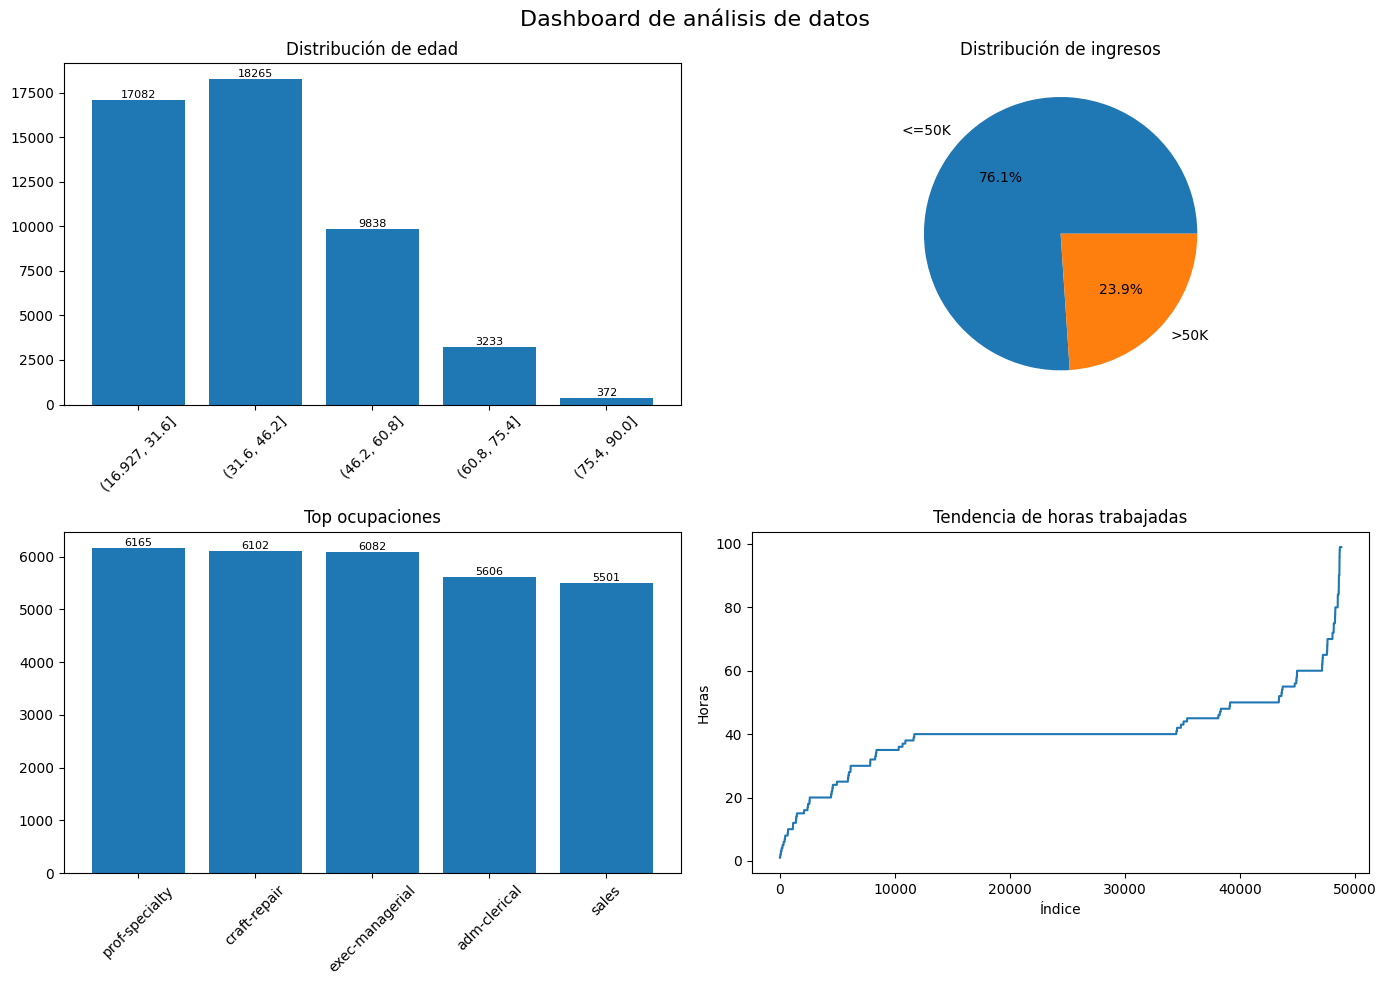

In [29]:

# Seleccionamos las columnas numéricas de interés para los histogramas
# 'edad', 'anios_educacion', 'horas_por_semana', 'ganancia_capital', 'perdida_capital'


# Crear figura
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Edad por rangos (barras con etiquetas)
df['edad_rango'] = pd.cut(df['edad'], bins=5)
conteo_edad = df['edad_rango'].value_counts().sort_index()

bars = axes[0,0].bar(conteo_edad.index.astype(str), conteo_edad.values)
for bar in bars:
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                   int(bar.get_height()), ha='center', va='bottom', fontsize=8)

axes[0,0].set_title("Distribución de edad")
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Ingresos (torta)
conteo_income = df['income_num'].value_counts()
axes[0,1].pie(conteo_income.values, labels=['<=50K', '>50K'], autopct='%1.1f%%')
axes[0,1].set_title("Distribución de ingresos")

# 3. Top ocupaciones (barras con etiquetas)
top_trabajos = df['ocupacion'].value_counts().head(5)

bars2 = axes[1,0].bar(top_trabajos.index, top_trabajos.values)
for bar in bars2:
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                   int(bar.get_height()), ha='center', va='bottom', fontsize=8)

axes[1,0].set_title("Top ocupaciones")
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Horas trabajadas (línea)
horas_sorted = df['horas_por_semana'].sort_values().reset_index(drop=True)

axes[1,1].plot(horas_sorted)
axes[1,1].set_title("Tendencia de horas trabajadas")
axes[1,1].set_xlabel("Índice")
axes[1,1].set_ylabel("Horas")

# Ajustes finales
plt.suptitle("Dashboard de análisis de datos", fontsize=16)
plt.tight_layout()

plt.show()

### Modelo de Árbol de Decisión para Clasificación

Implementaremos un modelo de árbol de decisión para clasificar los ingresos (`income_num`). Este modelo es más adecuado para variables objetivo binarias que la regresión lineal.

In [85]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score

# Inicializar y entrenar el modelo de Árbol de Decisión
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_dt = dt_model.predict(X_test_scaled)

# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred_dt)
report = classification_report(y_test, y_pred_dt)
conf_matrix = confusion_matrix(y_test, y_pred_dt)
prec = precision_score(y_test, y_pred_dt)

print(f"Precisión (Accuracy) del modelo de Árbol de Decisión: {accuracy:.2f}")
print("\nReporte de Clasificación:\n", report)
print("\nMatriz de Confusión:\n", conf_matrix)

Precisión (Accuracy) del modelo de Árbol de Decisión: 0.82

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.84      0.93      0.89     11068
           1       0.69      0.46      0.55      3569

    accuracy                           0.82     14637
   macro avg       0.77      0.70      0.72     14637
weighted avg       0.81      0.82      0.80     14637


Matriz de Confusión:
 [[10338   730]
 [ 1929  1640]]


Aunque el modelo presenta una precisión general del 82%, se evidencia un desempeño desigual entre clases. El modelo clasifica correctamente la mayoría de los casos de ingresos bajos (recall = 0.93), pero presenta dificultades para identificar individuos con ingresos altos, con un recall de solo 0.46.

##Función para comparar modelos

In [78]:
def evaluate_model(name, fitted_model, X_eval, y_eval, cv_scores=None):
    y_pred_local = fitted_model.predict(X_eval)
    y_pred_proba_local = fitted_model.predict_proba(X_eval)[:, 1]

    results = {
        'model': name,
        'accuracy': accuracy_score(y_eval, y_pred_local),
        'precision': precision_score(y_eval, y_pred_local),
        'recall': recall_score(y_eval, y_pred_local),
        'f1': f1_score(y_eval, y_pred_local),
        'auc_test': roc_auc_score(y_eval, y_pred_proba_local),
    }

    if cv_scores is not None:
        results['auc_cv_mean'] = cv_scores.mean()
        results['auc_cv_std'] = cv_scores.std()

    return results

In [86]:
## Implementar CV
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=52)

scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc'
)

print('CV scores:', scores)
print('Mean AUC:', scores.mean())


CV scores: [0.86191584 0.86622552 0.85717614 0.86727257 0.86504679]
Mean AUC: 0.8635273722893906


##Arboles de decisión, con LabelEncoder

A continuación convertiremos variables categóricas en números, con el objetivo de mejorar el modelo de árboles de decisión.

In [96]:
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

df_processed = df.copy()

for col in df_processed.select_dtypes(include=['object', 'category']).columns:
    # If the column is of 'category' dtype, ensure 'unknown' is a valid category
    if pd.api.types.is_categorical_dtype(df_processed[col]):
        if 'unknown' not in df_processed[col].cat.categories:
            df_processed[col] = df_processed[col].cat.add_categories('unknown')
    # Now fill NaNs with 'unknown'. This will work for both object and category dtypes.
    df_processed[col] = df_processed[col].fillna('unknown')

# Codificar categóricas, incluyendo las de tipo 'category'
for col in df_processed.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])


y = df_processed['income_num']

# Entrenar modelo
ad_model = DecisionTreeClassifier(random_state=42)
ad_model.fit(X, y)


ad_model.fit(X_train, y_train)
ad_cv_scores = cross_val_score(ad_model, X_train, y_train, cv=cv, scoring='roc_auc')
ad_results = evaluate_model('Arboles con labelencoder', ad_model, X_test, y_test, ad_cv_scores)
ad_results

# Feature importance
feat_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

# Guardar CSV
feat_importance.to_csv('feature_importance.csv', index=False)

feat_importance.head(10)

,feature,importance
1,peso_muestral,0.236290
28,estado_civil_married-civ-spouse,0.198694
2,anios_educacion,0.121632
0,edad,0.112985
3,horas_por_semana,0.079441
99,grupo_edad_Adulto,0.016640
36,ocupacion_exec-managerial,0.014298
9,tipo_trabajo_self-emp-not-inc,0.011542
7,tipo_trabajo_private,0.011003
35,ocupacion_craft-repair,0.009257


Los resultados muestran que factores como la relación familiar, la educación y la edad son los principales determinantes del nivel de ingresos. Esto evidencia que tanto variables socioeconómicas como laborales influyen significativamente en la probabilidad de percibir ingresos superiores a 50K.” En el próximo modelo se van a eliminar las variables correspondientes a ganancia y perdida de capital por considerar que son redundantes en el momento de predecir los ingresos de una persona.

**Random forest**

In [88]:
df = pd.get_dummies(df, drop_first=True)
from sklearn.ensemble import RandomForestClassifier

# Separar variables
# 'income_num' es nuestra variable target
# 'ingresos_>50k' es la versión one-hot-encoded de la target (derivada de 'ingresos') y debe ser eliminada de las características.
# 'ganancia_capital' y 'ganancia_capital' también serán eliminadas de las características porque dada su naturaleza son variables redundantes en la explicación de la target
X = df.drop(columns=['income_num', 'ingresos_>50k', 'ganancia_capital', 'perdida_capital'])
y = df['income_num']

# Entrenar Modelo
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='roc_auc')
rf_results = evaluate_model('Random Forest', rf_model, X_test, y_test, rf_cv_scores)
rf_results

{'model': 'Random Forest',
 'accuracy': 0.8328209332513493,
 'precision': 0.7799401197604791,
 'recall': 0.4379377977024377,
 'f1': 0.5609187152341647,
 'auc_test': np.float64(0.8633761308249783),
 'auc_cv_mean': np.float64(0.8635273722893906),
 'auc_cv_std': np.float64(0.0036482970202086013)}

In [89]:
feat_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

feat_importance.head(10)

,feature,importance
1,peso_muestral,0.236290
28,estado_civil_married-civ-spouse,0.198694
2,anios_educacion,0.121632
0,edad,0.112985
3,horas_por_semana,0.079441
99,grupo_edad_Adulto,0.016640
36,ocupacion_exec-managerial,0.014298
9,tipo_trabajo_self-emp-not-inc,0.011542
7,tipo_trabajo_private,0.011003
35,ocupacion_craft-repair,0.009257


In [90]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print("Accuracy promedio:", scores.mean())

Accuracy promedio: 0.77692150030744


En este nuevo modelo de Random Forest aumenta la importancia de variables como estado civil, años de educación y estado civil diferente a casado y mejora las métricas del modelo.

## Comparación con el modelo de árboles de decisión

In [98]:
baseline_results = evaluate_model('DecisionTreeClassifier', dt_model, X_test, y_test, scores)
comparison_df = pd.DataFrame([
    baseline_results,
    ad_results,
    rf_results
]).round(4)

comparison_df.sort_values('f1', ascending=False)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


,model,accuracy,precision,recall,f1,auc_test,auc_cv_mean,auc_cv_std
2,Random Forest,0.8328,0.7799,0.4379,0.5609,0.8634,0.8635,0.0036
1,Arboles con labelencoder,0.8180,0.6912,0.4584,0.5512,0.7953,0.7881,0.0082
0,DecisionTreeClassifier,0.7762,0.6198,0.2124,0.3164,0.5852,0.7769,0.0030


El análisis comparativo de modelos evidencia que el RandomForest presenta el mejor desempeño global. Este modelo alcanza los valores más altos en accuracy, precision, F1-score y AUC, lo que indica una mayor capacidad para discriminar entre individuos con ingresos menores y mayores a 50K. Además, la baja desviación estándar en la validación cruzada sugiere que su rendimiento es estable y consistente frente a distintas particiones de los datos.

Un hallazgo relevante es que, a pesar de las diferencias entre modelos, todos presentan dificultades para identificar correctamente la clase minoritaria (ingresos >50K), lo cual se refleja en valores de recall relativamente bajos. Este comportamiento puede atribuirse al desbalance de los dos grupos (ingresos altos e ingresos bajos) y sugiere la necesidad de aplicar técnicas adicionales, como el ajuste de pesos, el balanceo de datos o la optimización del umbral de decisión.

Por último, es importante resaltar que tanto el análisis de los datos (validaciones de cruce de variables), como los gráficos aportados, evidencian brechas muy significativas en los ingresos que se explican con variables como: raza, sexo, región y nivel educativo, lo cual sugiere una urgencia en materia de políticas de inclusión y equidad por parte de los gobiernos, para mejorar las condiciones iniciales de las personas.